# 5-Wege-Benchmark: Decoder-Only vs. Encoder-Decoder Modelle
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook visualisiert die Ergebnisse des 5-Wege-Modellvergleichs auf dem Lebenshilfe-Testset:
1. **Decoder-Only Basismodell (`Qwen2.5-1.5B`):** Unberührte **Few-Shot Baseline** mit In-Context-Learning.
2. **Decoder-Only SFT Modell:** Supervised Fine-Tuned LoRA Adapter auf Qwen.
3. **Decoder-Only DPO Modell:** Preference-Aligned LoRA Adapter auf Qwen.
4. **Encoder-Decoder SFT Modell:** Feinabgestimmtes `mBART-50`.
5. **Encoder-Decoder DPO Modell:** Direct Preference Optimized `mBART-50`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Arbeitsverzeichnis robust auf Projekt-Root setzen
while not (os.path.exists(".git") or os.path.exists("data")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())

## 1. 5-Wege-Benchmark-Ergebnisse laden

In [2]:
# ===============================================================================
# 1. ERGEBNIS-DATEN EINLESEN (5-Wege-Benchmark-Ergebnisse)
# ===============================================================================
CSV_PATH = "results/evaluation/benchmark_5way_decoder_vs_encoder_decoder.csv"
if not os.path.exists(CSV_PATH):
    CSV_PATH = "../../../results/evaluation/benchmark_5way_decoder_vs_encoder_decoder.csv"

df_eval = pd.read_csv(CSV_PATH)
print(f"5-Wege-Benchmark erfolgreich geladen: {len(df_eval)} Artikel aus {CSV_PATH}")
display(df_eval.head())

## 2. Wissenschaftliche 5-Wege-Gesamtvergleichstabelle
Systematischer Vergleich über alle 5 Modellierungsansätze.

In [7]:
def format_mean_std(values):
    return f"{np.mean(values):.4f} ± {np.std(values):.4f}"

models_config = [
    ("1. Few-Shot Baseline (Qwen-1.5B)", "r_style_dec_fs", "r_sem_as_dec_fs", "composite_dec_fs", "lix_dec_fs", "flesch_dec_fs"),
    ("2. Decoder-Only SFT (Qwen-1.5B)", "r_style_dec_sft", "r_sem_as_dec_sft", "composite_dec_sft", "lix_dec_sft", "flesch_dec_sft"),
    ("3. Decoder-Only DPO (Qwen-1.5B)", "r_style_dec_dpo", "r_sem_as_dec_dpo", "composite_dec_dpo", "lix_dec_dpo", "flesch_dec_dpo"),
    ("4. Encoder-Decoder SFT (mBART-50)", "r_style_enc_sft", "r_sem_as_enc_sft", "composite_enc_sft", "lix_enc_sft", "flesch_enc_sft"),
    ("5. Encoder-Decoder DPO (mBART-50)", "r_style_enc_dpo", "r_sem_as_enc_dpo", "composite_enc_dpo", "lix_enc_dpo", "flesch_enc_dpo"),
]

rows = []
for name, c_st, c_sm, c_tot, c_lix, c_fl in models_config:
    rows.append({
        "Modell / Paradigma": name,
        "Simplicity (R_style)": format_mean_std(df_eval[c_st]),
        "SBERT-Quelltreue (R_sem)": format_mean_std(df_eval[c_sm]),
        "Composite Total Reward": format_mean_std(df_eval[c_tot]),
        "LIX Index (↓)": format_mean_std(df_eval[c_lix]),
        "Flesch DE (↑)": format_mean_std(df_eval[c_fl]),
    })

df_master_table = pd.DataFrame(rows)
print("=" * 105)
print("  📊 WISSENSCHAFTLICHE GESAMT-VERGLEICHSTABELLE (5-WEGE-BENCHMARK, N=37)")
print("=" * 105)
display(df_master_table)

  📊 WISSENSCHAFTLICHE GESAMT-VERGLEICHSTABELLE (5-WEGE-BENCHMARK, N=37)


,Modell / Paradigma,Simplicity (R_style),SBERT-Quelltreue (R_sem),Composite Total Reward,LIX Index (↓),Flesch DE (↑)
0,1. Few-Shot Baseline (Qwen-1.5B),0.7382 ± 0.1660,0.7259 ± 0.0733,0.7345 ± 0.1172,35.9019 ± 13.2058,67.8945 ± 16.7020
1,2. Decoder-Only SFT (Qwen-1.5B),0.7288 ± 0.1842,0.7622 ± 0.0714,0.7388 ± 0.1400,40.8467 ± 29.7738,59.8563 ± 35.5639
2,3. Decoder-Only DPO (Qwen-1.5B),0.7288 ± 0.1842,0.7622 ± 0.0714,0.7388 ± 0.1400,40.8467 ± 29.7738,59.8563 ± 35.5639
3,4. Encoder-Decoder SFT (mBART-50),0.6186 ± 0.1650,0.8882 ± 0.0452,0.6995 ± 0.1115,37.4725 ± 5.5708,68.2729 ± 9.2394
4,5. Encoder-Decoder DPO (mBART-50),0.2052 ± 0.1076,0.8537 ± 0.0696,0.3998 ± 0.0795,49.7815 ± 11.0374,47.2054 ± 17.7963


## 3. Publikationsreife Visualisierungen (Boxplots über alle 5 Modellvarianten)

/tmp/ipykernel_1137708/94918983.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_plot, x="Modell", y="Simplicity (R_style)", palette=palette)
/tmp/ipykernel_1137708/94918983.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_plot, x="Modell", y="SBERT-Treue (R_sem)", palette=palette)
/tmp/ipykernel_1137708/94918983.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], data=df_plot, x="Modell", y="Composite Reward", palette=palette)


Vergleichs-Plot gespeichert unter: results/plots/benchmark_5way_decoder_vs_encoder_decoder.png


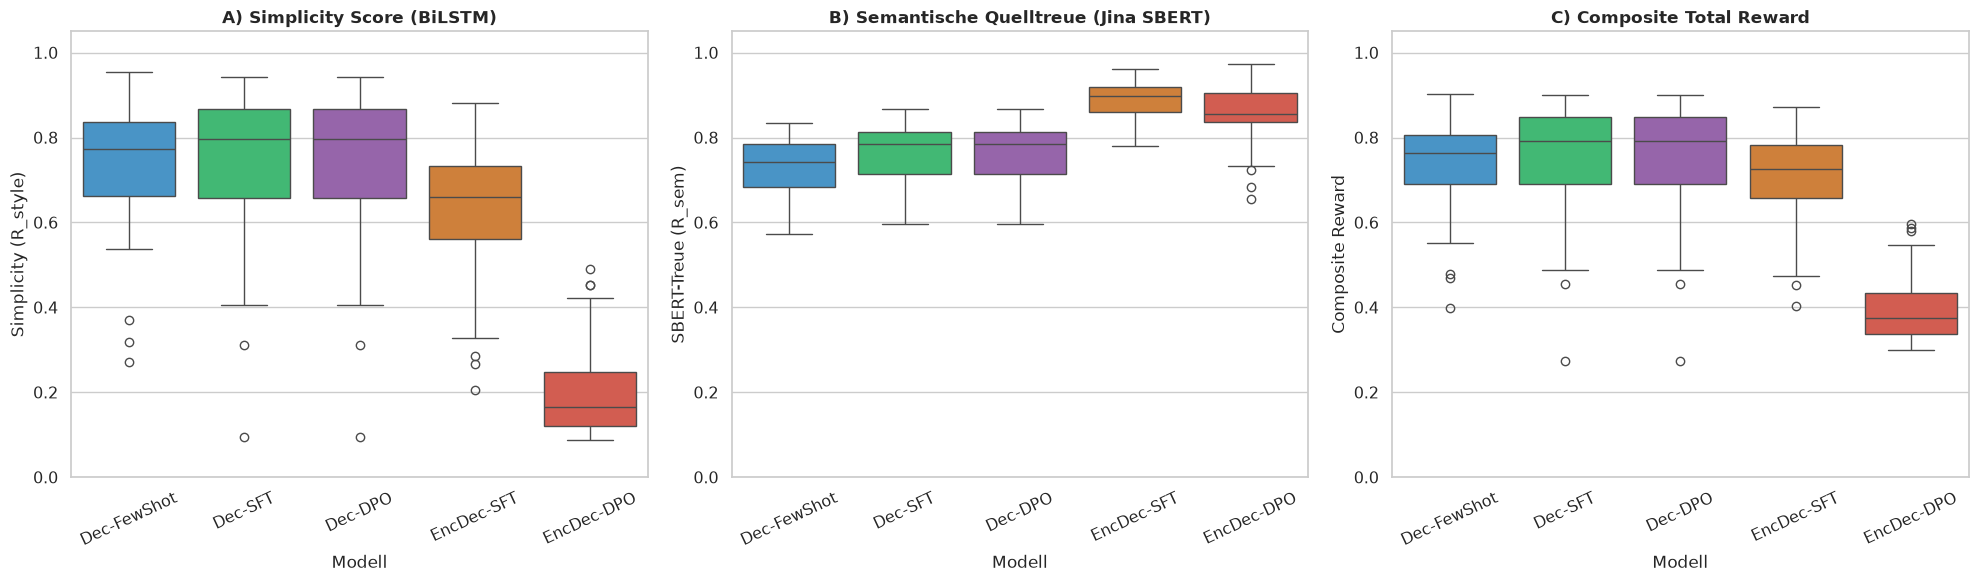

In [8]:
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_data = []
short_names = [
    ("Dec-FewShot", "r_style_dec_fs", "r_sem_as_dec_fs", "composite_dec_fs"),
    ("Dec-SFT", "r_style_dec_sft", "r_sem_as_dec_sft", "composite_dec_sft"),
    ("Dec-DPO", "r_style_dec_dpo", "r_sem_as_dec_dpo", "composite_dec_dpo"),
    ("EncDec-SFT", "r_style_enc_sft", "r_sem_as_enc_sft", "composite_enc_sft"),
    ("EncDec-DPO", "r_style_enc_dpo", "r_sem_as_enc_dpo", "composite_enc_dpo"),
]

for model_name, col_style, col_sem, col_tot in short_names:
    for _, row in df_eval.iterrows():
        plot_data.append({
            "Modell": model_name,
            "Simplicity (R_style)": row[col_style],
            "SBERT-Treue (R_sem)": row[col_sem],
            "Composite Reward": row[col_tot],
        })

df_plot = pd.DataFrame(plot_data)
palette = ["#3498db", "#2ecc71", "#9b59b6", "#e67e22", "#e74c3c"]

# 1. Simplicity
sns.boxplot(ax=axes[0], data=df_plot, x="Modell", y="Simplicity (R_style)", palette=palette)
axes[0].set_title("A) Simplicity Score (BiLSTM)", fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=25)

# 2. SBERT
sns.boxplot(ax=axes[1], data=df_plot, x="Modell", y="SBERT-Treue (R_sem)", palette=palette)
axes[1].set_title("B) Semantische Quelltreue (Jina SBERT)", fontweight="bold")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=25)

# 3. Composite Reward
sns.boxplot(ax=axes[2], data=df_plot, x="Modell", y="Composite Reward", palette=palette)
axes[2].set_title("C) Composite Total Reward", fontweight="bold")
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plot_path = "results/plots/benchmark_5way_decoder_vs_encoder_decoder.png"
plt.savefig(plot_path, dpi=300)
print(f"Vergleichs-Plot gespeichert unter: {plot_path}")
plt.show()

## 4. Qualitatives Side-by-Side Stichproben-Audit (Beispielartikel)

In [9]:
print("=" * 105)
print("  🔍 QUALITATIVE STICHPROBEN: SIDE-BY-SIDE VERGLEICH ALLER 5 MODELLE")
print("=" * 105)

for idx in range(min(3, len(df_eval))):
    row = df_eval.iloc[idx]
    print(f"\n{'='*105}")
    print(f"[ARTIKEL {idx+1}]: {row['title']}")
    print(f"{'='*105}")
    print(f"\n[1. AS-QUELLE]:\n{row['as_text'][:300]}...")
    print(f"\n[2. LS-REFERENZ]:\n{row['ls_reference'][:300]}...")
    
    print(f"\n--- [1] DECODER FEW-SHOT BASELINE (Qwen-1.5B) ---")
    print(row['pred_dec_fs'][:350] + ("..." if len(row['pred_dec_fs']) > 350 else ""))
    print(f"-> Scores: Style={row['r_style_dec_fs']:.3f} | SBERT(AS)={row['r_sem_as_dec_fs']:.3f} | Total={row['composite_dec_fs']:.3f}")
    
    print(f"\n--- [2] DECODER SFT MODELL (Qwen-1.5B) ---")
    print(row['pred_dec_sft'][:350] + ("..." if len(row['pred_dec_sft']) > 350 else ""))
    print(f"-> Scores: Style={row['r_style_dec_sft']:.3f} | SBERT(AS)={row['r_sem_as_dec_sft']:.3f} | Total={row['composite_dec_sft']:.3f}")
    
    print(f"\n--- [3] DECODER DPO MODELL (Qwen-1.5B) ---")
    print(row['pred_dec_dpo'][:350] + ("..." if len(row['pred_dec_dpo']) > 350 else ""))
    print(f"-> Scores: Style={row['r_style_dec_dpo']:.3f} | SBERT(AS)={row['r_sem_as_dec_dpo']:.3f} | Total={row['composite_dec_dpo']:.3f}")
    
    print(f"\n--- [4] ENCODER-DECODER SFT MODELL (mBART-50) ---")
    print(row['pred_enc_sft'][:350] + ("..." if len(row['pred_enc_sft']) > 350 else ""))
    print(f"-> Scores: Style={row['r_style_enc_sft']:.3f} | SBERT(AS)={row['r_sem_as_enc_sft']:.3f} | Total={row['composite_enc_sft']:.3f}")
    
    print(f"\n--- [5] ENCODER-DECODER DPO MODELL (mBART-50) ---")
    print(row['pred_enc_dpo'][:350] + ("..." if len(row['pred_enc_dpo']) > 350 else ""))
    print(f"-> Scores: Style={row['r_style_enc_dpo']:.3f} | SBERT(AS)={row['r_sem_as_enc_dpo']:.3f} | Total={row['composite_enc_dpo']:.3f}")
    print("-" * 105)

  🔍 QUALITATIVE STICHPROBEN: SIDE-BY-SIDE VERGLEICH ALLER 5 MODELLE

[ARTIKEL 1]: Artikel 1

[1. AS-QUELLE]:
Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit We...

[2. LS-REFERENZ]:
Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diesen Text geschrieben. Sie haben Ihre Meinung aufgeschrieben. Und sie haben Ihre Ideen aufgeschrieben. Diese Meinungen und Ideen heißen auch: Positionen ...

--- [1] DECODER FEW-SHOT BASELINE (Qwen-1.5B) ---
In Deutschland gibt es viele Arbeiter*. Sie arbeiten in verschiedenen Unternehmen. Zum Beispiel in Fabrik-Werkstätzen. Dort arbeiten die Arbeiter sehr lange Zeit. Und sie werden dort bezahlt. Aber jetzt wollen die